# 00 - EDA & Feature Sandbox (Bắt buộc)

Notebook này phục vụ mục đích:
1. Khám phá dữ liệu (EDA) trên tập mẫu (sample).
2. Đánh giá độ quan trọng và mức độ đóng đóng góp của các feature.
3. Tinh chỉnh danh sách feature trước khi đưa vào pipeline ETL chính thức (Notebook 01).

**Nguyên tắc:** Notebook-thin, gọi các helper từ `src/` để xử lý.


**Cập nhật mới nhất:** Đã loại bỏ hoàn toàn `speed_ratio`, `speed_delta`, `is_one_way`, `ward_district_id`. Giữ lại `traffic_index` như một tính năng động cốt lõi.

In [1]:
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Add project root to sys.path
cwd = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in [cwd] + list(cwd.parents) if (p / 'src').exists()), cwd)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

from src.pipelines.notebook01_etl import DEFAULT_CORRIDOR_IDS
from src.ml.feature_contract import DYNAMIC_FEATURE_COLS

## 1. Cấu hình lấy dữ liệu mẫu

In [2]:
START_DATE = '2026-03-25'
END_DATE = '2026-04-26'
CORRIDOR_IDS = DEFAULT_CORRIDOR_IDS[:10]  # Tăng lên 10 hành lang để đa dạng địa lý

print(f"Lấy dữ liệu từ {START_DATE} đến {END_DATE} cho 10 hành lang đại diện.")

Lấy dữ liệu từ 2026-03-25 đến 2026-04-26 cho 10 hành lang đại diện.


## 2. Tải dữ liệu từ Mart/Warehouse

In [3]:
# Ở bước này, ta load mẫu đa dạng và đảm bảo đủ 10 hành lang
import random
from src.data_access.warehouse_repository import get_segments_in_corridor
from src.data_access.forecast_mart_repository import load_forecast_mart_by_segments
from src.core.database import get_engine

engine = get_engine()
sample_segments = []
PER_CORRIDOR_LIMIT = 30 # Lấy 30 segments cho mỗi hành lang

random.seed(42)
for cid in CORRIDOR_IDS:
    segments = get_segments_in_corridor(cid)
    # Xáo trộn segments trong hành lang hiện tại
    random.shuffle(segments)
    # Lấy tối đa 30 segments của hành lang này
    sample_segments.extend(segments[:PER_CORRIDOR_LIMIT])

# Loại bỏ trùng lặp nếu có (trường hợp segment thuộc nhiều hành lang)
sample_segments = list(set(sample_segments))

df = load_forecast_mart_by_segments(
    engine=engine,
    segment_ids=sample_segments,
    start_date=START_DATE,
    end_date=END_DATE
)

print(f"Đã tải {len(df)} dòng dữ liệu cho {len(sample_segments)} segments đại diện đủ cho {len(CORRIDOR_IDS)} hành lang.")
df.head()

Đã tải 340021 dòng dữ liệu cho 293 segments đại diện đủ cho 10 hành lang.


,segment_key,timestamp,current_speed_kmh,traffic_index,delay_seconds,quality_flag,congestion_level,default_lane_count,free_flow_speed_kmh,tomtom_frc,weather_key,day_of_week,shift_code,is_peak_hour,is_business_hours,is_weekend,time_sin,time_cos
0,1990653039078628,2026-03-25 06:08:48.740356,46.0,0.00,0.0,9,0.0,2,46.0,2.0,500.0,3,EARLY_MORNING,1.0,0.0,0.0,0.999391,-0.034899
1,1990653039078628,2026-03-25 06:32:35.007854,46.0,0.00,0.0,9,0.0,2,46.0,2.0,500.0,3,EARLY_MORNING,1.0,0.0,0.0,0.990268,-0.139173
2,1990653039078628,2026-03-25 06:56:19.237959,46.0,0.00,0.0,9,0.0,2,46.0,2.0,500.0,3,EARLY_MORNING,1.0,0.0,0.0,0.970296,-0.241922
3,1990653039078628,2026-03-25 07:19:37.392377,46.0,0.00,0.0,9,0.0,2,46.0,2.0,500.0,3,MORNING_PEAK,1.0,0.0,0.0,0.941176,-0.337917
4,1990653039078628,2026-03-25 07:43:31.341962,39.0,0.15,102.0,9,1.0,2,46.0,2.0,500.0,3,MORNING_PEAK,1.0,0.0,0.0,0.900698,-0.434445


## 3. Phân tích đặc trưng (Feature Analysis)

**Lưu ý quan trọng về Model Alignment:**
Để mô phỏng đúng điều kiện thực tế, ta thiết lập phân tích như sau:
- **Target (Nhãn):** Mức độ ùn tắc tại thời điểm $T$.
- **Context Features (Biến bối cảnh):** Các đặc trưng tại thời điểm $T$ (Weather, Time, v.v.) vì chúng có thể dự đoán hoặc biết trước.
- **Dynamic Features (Biến động lực):** Sử dụng dữ liệu quá khứ từ **$T-15m$ đến $T-180m$** (12 bước trễ). 
**Tuyệt đối không sử dụng Dynamic Feature tại thời điểm $T$** để tránh rò rỉ dữ liệu, vì tại thời điểm cần ra quyết định dự báo cho 15p tới, ta chưa có dữ liệu tốc độ/delay của chính khung giờ đó.

Đang khởi tạo dữ liệu chuẩn bị cho phân tích...


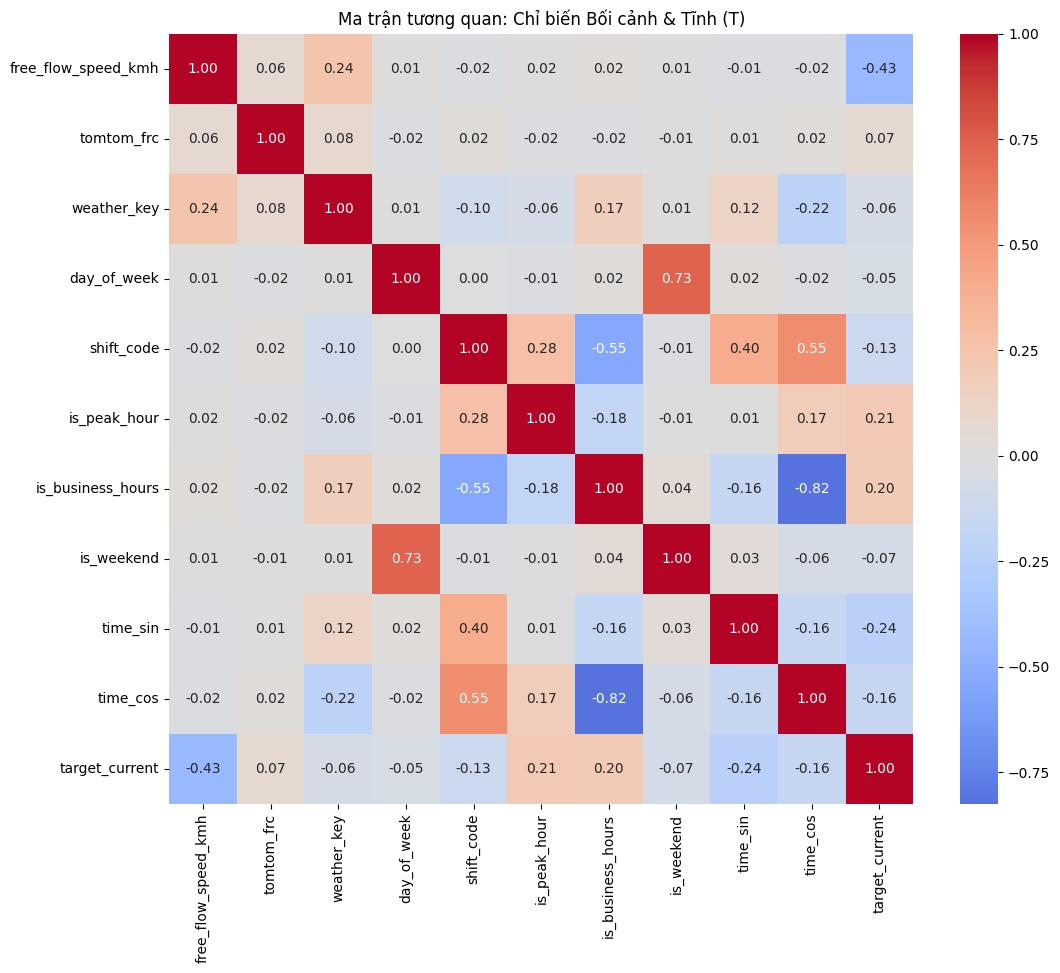

In [4]:
# 3.2 Ma trận tương quan bối cảnh (Context/Static vs Target)
from sklearn.preprocessing import LabelEncoder

# Kiểm tra và khởi tạo dữ liệu nếu chưa có
if 'context_cols' not in locals():
    print("Đang khởi tạo dữ liệu chuẩn bị cho phân tích...")
    n_lags = 12
    dynamic_features = DYNAMIC_FEATURE_COLS
    dropped_features = ['quality_flag', 'default_lane_count']
    
    df_eda = df.copy().sort_values(['segment_key', 'timestamp'])
    df_eda['target_current'] = df_eda['congestion_level']
    
    lagged_cols = []
    for feat in dynamic_features:
        for lag in range(1, n_lags + 1):
            col_name = f"{feat}_lag_{lag}"
            df_eda[col_name] = df_eda.groupby('segment_key')[feat].shift(lag)
            lagged_cols.append(col_name)
            
    exclude_cols = lagged_cols + dynamic_features + dropped_features + ['timestamp', 'segment_key', 'congestion_level', 'target_current', 'target_future']
    context_cols = [c for c in df_eda.columns if c not in exclude_cols]
    
    le = LabelEncoder()
    for col in context_cols:
        if df_eda[col].dtype == 'object' or col in ['shift_code', 'day_of_week', 'weather_key', 'tomtom_frc']:
            df_eda[col] = le.fit_transform(df_eda[col].astype(str))
    
    df_eda = df_eda.dropna(subset=lagged_cols)

# Vẽ ma trận tương quan
cols_to_corr = context_cols + ['target_current']
corr = df_eda[cols_to_corr].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Ma trận tương quan: Chỉ biến Bối cảnh & Tĩnh (T)")
plt.show()

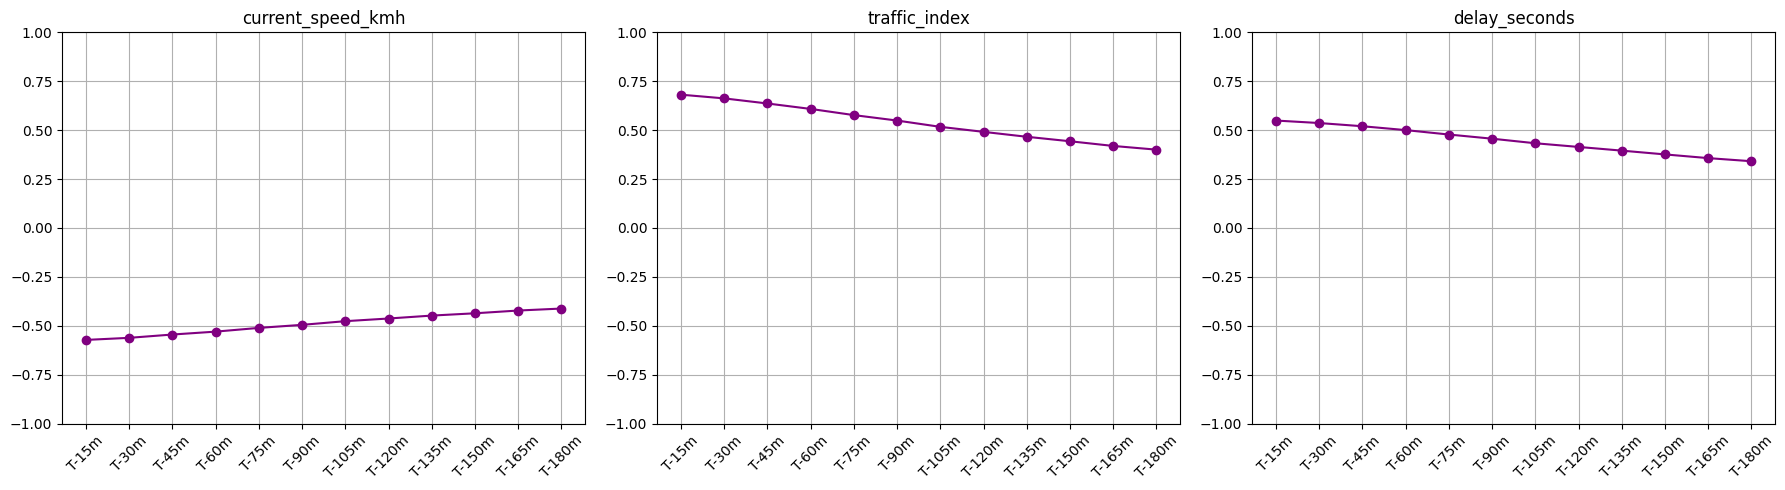

In [5]:
# 3.3 Phân tích tương quan của chuỗi Dynamic (T-15m -> T-180m)
plt.figure(figsize=(18, 5))
for i, feat in enumerate(dynamic_features):
    lags = [f"{feat}_lag_{lag}" for lag in range(1, n_lags + 1)]
    corr_vals = [df_eda[[col, 'target_current']].corr().iloc[0, 1] for col in lags]
    
    plt.subplot(1, 3, i+1)
    plt.plot(range(1, n_lags + 1), corr_vals, marker='o', color='purple')
    plt.xticks(range(1, n_lags + 1), [f"T-{l*15}m" for l in range(1, n_lags + 1)], rotation=45)
    plt.title(f"{feat}")
    plt.grid(True)
    plt.ylim(-1, 1)

plt.tight_layout()
plt.show()

## 4. Đánh giá mức độ quan trọng (Feature Importance - Sơ bộ)

In [6]:
from sklearn.ensemble import RandomForestClassifier

# 4. Đánh giá Tầm quan trọng (Feature Importance)
X = df_eda[lagged_cols + context_cols].copy()
y = df_eda['target_current'].astype(int)

model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X, y)

importance_df = pd.DataFrame({'feature': X.columns, 'importance': model.feature_importances_})

# 4.1 Biểu đồ bối cảnh (Chỉ hiện Context features)
ctx_imp = importance_df[importance_df['feature'].isin(context_cols)].sort_values('importance', ascending=False)

plt.figure(figsize=(10, 10))
sns.barplot(x='importance', y='feature', data=ctx_imp)
plt.title("Tầm quan trọng của các biến bối cảnh (Context Features at T)")
plt.show()

# 4.2 Biểu đồ đường cho Dynamic Lags
plt.figure(figsize=(18, 5))
colors = ['r', 'g', 'b', 'orange']
for i, feat in enumerate(dynamic_features):
    feat_imps = []
    for lag in range(1, n_lags + 1):
        col_name = f"{feat}_lag_{lag}"
        imp_val = importance_df[importance_df['feature'] == col_name]['importance'].values[0]
        feat_imps.append(imp_val)
    
    plt.subplot(1, 3, i+1)
    plt.plot(range(1, n_lags + 1), feat_imps, marker='s', color=colors[i])
    plt.xticks(range(1, n_lags + 1), [f"T-{l*15}m" for l in range(1, n_lags + 1)], rotation=45)
    plt.title(f"Importance: {feat}")
    plt.grid(True)

plt.tight_layout()
plt.show()

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

## 5. Kết luận & Tinh chỉnh

Dựa trên phân tích Tầm quan trọng (Feature Importance) và tương quan, ta quyết định tinh chỉnh bộ tính năng như sau:

**1. Danh sách Feature loại bỏ:**
- `quality_flag`: Ít biến động hoặc không đóng góp đáng kể vào mô hình.
- `default_lane_count`: Thông tin tĩnh không giúp phân biệt mức độ ùn tắc linh hoạt.
- `speed_ratio`: Đã loại bỏ để đơn giản hóa input (thay thế bằng raw speed).
- `speed_delta`: Loại bỏ do tính toán delta gây nhiễu.
- `is_one_way`, `ward_district_id`: Thông tin tĩnh không cần thiết.

**2. Danh sách Feature giữ lại:**
- `current_speed_kmh`, `traffic_index`, `delay_seconds`: Các biến động lực học chính (Core Dynamic Features).
- `time_sin`, `time_cos`, `is_peak_hour`, `is_weekend`, `is_business_hours`: Các biến bối cảnh thời gian.
- `tomtom_frc`, `weather_key`, `shift_code`, `day_of_week`: Các biến phân loại.

**3. Quyết định:**
- Đã cập nhật `src/ml/feature_contract.py` để phản ánh các thay đổi trên.
- `traffic_index` được giữ lại như một dynamic feature quan trọng.
- Notebook 01 (ETL) sẽ tự động áp dụng contract mới này.

**Hành động tiếp theo:** Chạy lại Notebook 01 để làm sạch tập dữ liệu chuẩn bị cho huấn luyện RL.